In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# The file location
merged_stats = "https://raw.githubusercontent.com/csc442-team11/MLB-Data-Analysis/refs/heads/main/Datasets/mlb-player-stats-Batters-2023-2024-cleaned.csv"


# Create dataframe
df = pd.read_csv(merged_stats)

First, I want to see the distribution of the three statistics I will be exploring


*   OBP (on base percentage)
*   Stolen Bases
*   Position





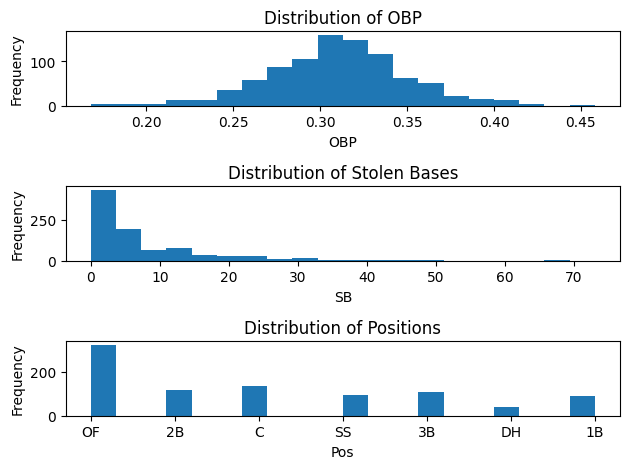

In [ ]:
# Histogram of OBS
plt.subplot(3,1,1)
plt.hist(df['OBP'], bins=20)
plt.title('Distribution of OBP')
plt.xlabel('OBP')
plt.ylabel('Frequency')

# Histogram of Stolen Bases
plt.subplot(3,1,2)
plt.hist(df['SB'], bins=20)
plt.title('Distribution of Stolen Bases')
plt.xlabel('SB')
plt.ylabel('Frequency')

# Histogram of Positions
plt.subplot(3,1,3)
plt.hist(df['Pos'], bins=20)
plt.title('Distribution of Positions')
plt.xlabel('Pos')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Then, I make scatterplots comparing OBP vs Pos, Stolen Base vs Pos, and OBP vs Stolen Base. We want to check if there is a strong correlation between any of these variables.

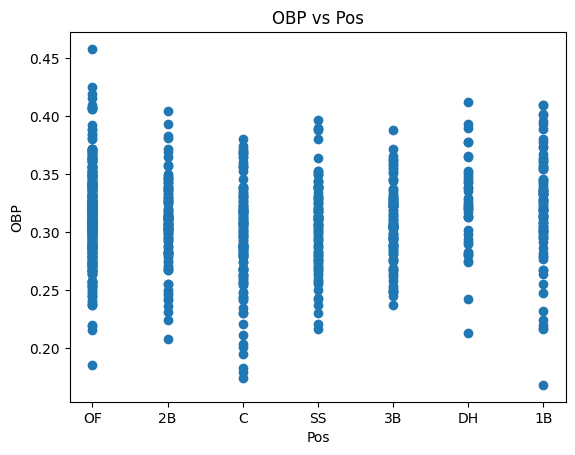

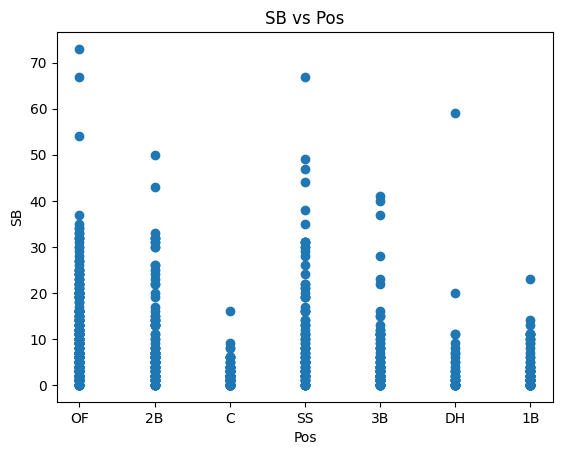

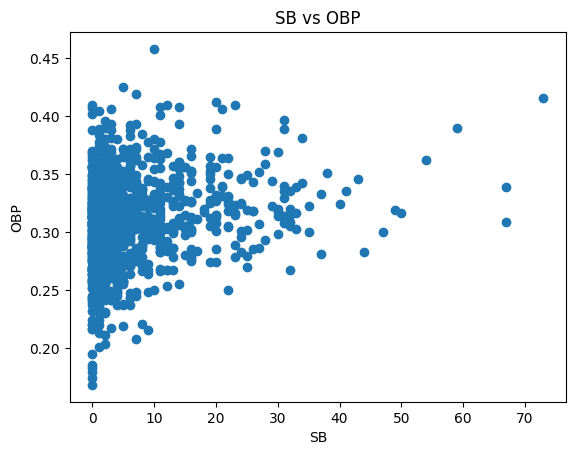

In [ ]:
# OBP vs Pos
plt.scatter(df['Pos'], df['OBP'])
plt.title('OBP vs Pos')
plt.xlabel('Pos')
plt.ylabel('OBP')
plt.show()

# SB vs Pos
plt.scatter(df['Pos'], df['SB'])
plt.title('SB vs Pos')
plt.xlabel('Pos')
plt.ylabel('SB')
plt.show()

# OBP vs SB
plt.scatter(df['SB'], df['OBP'])
plt.title('OBP vs SB')
plt.xlabel('SB')
plt.ylabel('OBP')
plt.show()


I want to see how these statistics break down for each team.

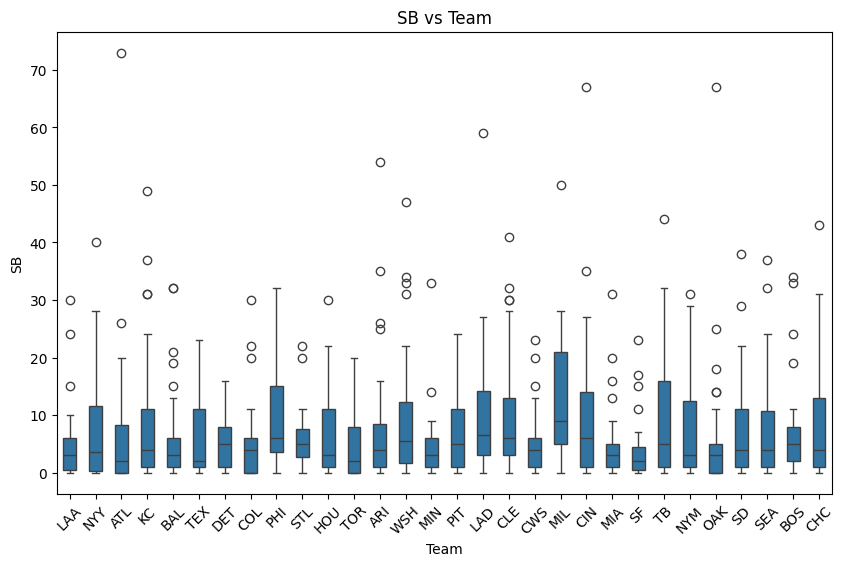

Text(0, 0.5, 'OBP')

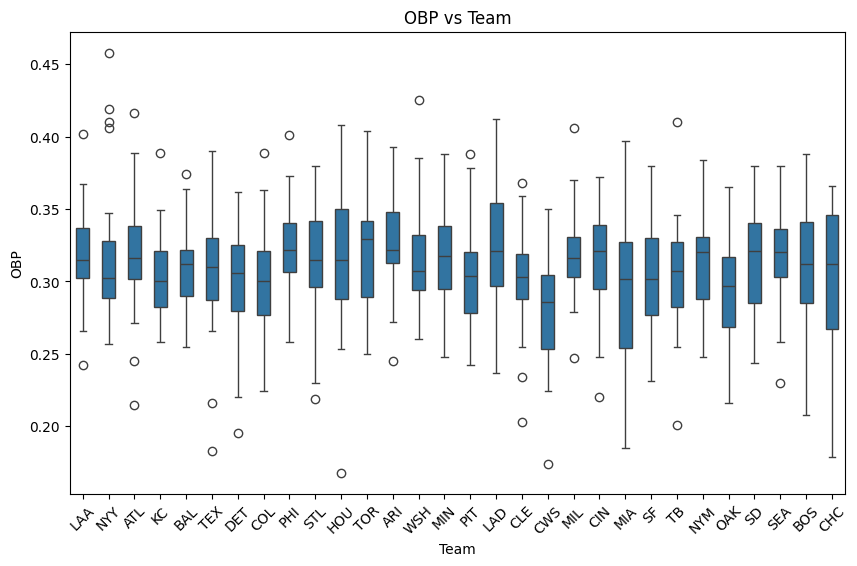

In [ ]:
# SB vs Team
plt.figure(figsize=(10, 6))
sns.boxplot(x='Team', y='SB', data=df, width = 0.5)
plt.title('SB vs Team')
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.ylabel('SB')
plt.show()

# OBP vs Team
plt.figure(figsize=(10, 6))
sns.boxplot(x='Team', y='OBP', data=df, width = 0.5)
plt.title('OBP vs Team')
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.ylabel('OBP')

Then, I want to aggregate these statistics to see how well teams do

In [ ]:
# Group by team and aggregate these stats
# Time this process
import time
start = time.time()
speed_stats = df.groupby('Team').agg({
    'OBP': 'mean',
    'SB': 'sum'
}).reset_index()

# Remove the teams below the average OBP
avg_obp = speed_stats['OBP'].mean()
speed_stats = speed_stats[speed_stats['OBP'] > avg_obp]

# Only keep the top 10 in stolen bases. These are likely the fastest teams
speed_stats = speed_stats.nlargest(10, 'SB').reset_index(drop=True)

display(speed_stats)

print(time.time() - start)

,Team,OBP,SB
0,CIN,0.315514,378
1,LAD,0.323688,323
2,MIL,0.319720,315
3,WSH,0.316357,286
4,ARI,0.326571,280
5,PHI,0.322370,275
6,ATL,0.317889,245
7,BOS,0.312914,243
8,SEA,0.316867,235
9,NYM,0.313871,234


0.015995025634765625


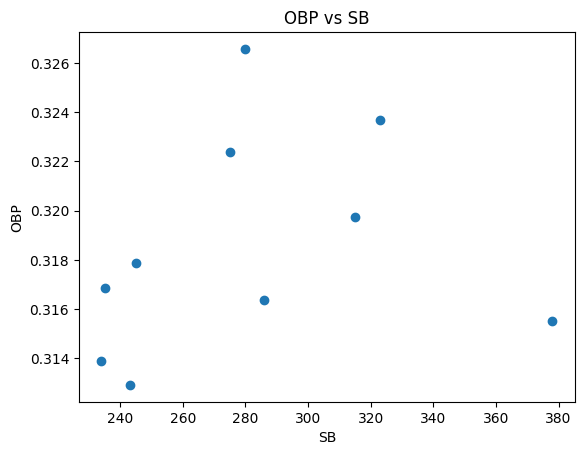

In [ ]:
# Now let's see OBP vs SB for the fasest teams
# OBP vs SB
plt.scatter(speed_stats['SB'], speed_stats['OBP'])
plt.title('OBP vs SB')
plt.xlabel('SB')
plt.ylabel('OBP')
plt.show()

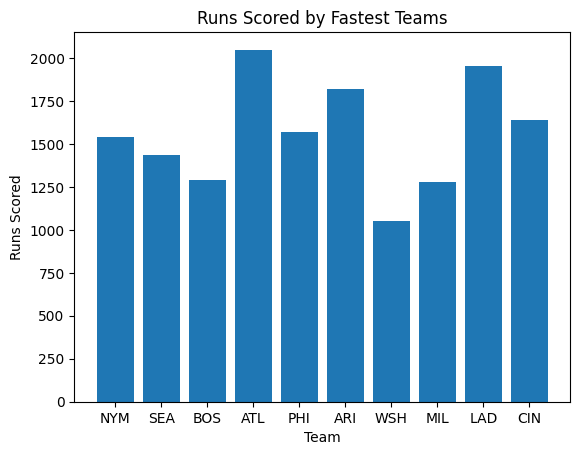

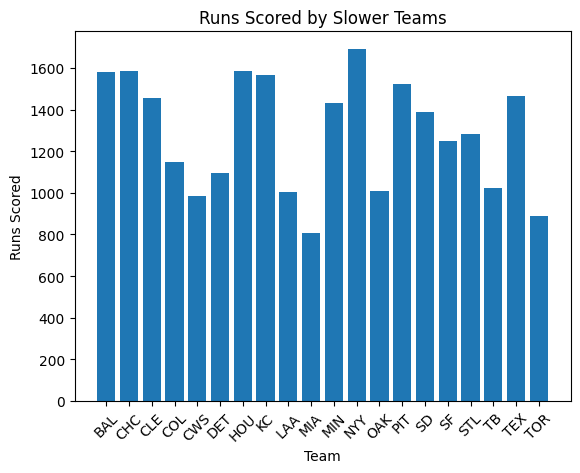

In [92]:
# Check how many runs each of the fastest teams scored

# First, only keep the teams from the original dataset that are in the speed_stats
fastest_teams = df[df['Team'].isin(speed_stats['Team'])]
slower_teams = df[~df['Team'].isin(speed_stats['Team'])]
# Now, group by team and sum the runs scored
runs_scored = fastest_teams.groupby('Team')['R'].sum().reset_index()
runs_scored_slow = slower_teams.groupby('Team')['R'].sum().reset_index()

# Merge with fastest teams
runs_scored = pd.merge(runs_scored, speed_stats, on='Team').sort_values(by='SB', ascending=True).reset_index(drop=True)

# Display barchart of runs scored in order of fastest teams
plt.bar(runs_scored['Team'], runs_scored['R'])
plt.title('Runs Scored by Fastest Teams')
plt.xlabel('Team')
plt.ylabel('Runs Scored')
plt.show()

# Display barchart of the runs scored of slower teams
plt.bar(runs_scored_slow['Team'], runs_scored_slow['R'])
plt.title('Runs Scored by Slower Teams')
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.ylabel('Runs Scored')
plt.show()